# Week 06 · Day 1 — EDA Precision Lab

**Real Relationships vs. Real Comparisons, and Verified Findings**

Dataset: `data/students.csv` (600 rows × 6 cols, verbatim spec, `seed=21`) — clean by
design. Today has no cleaning phase; the entire focus is visualization precision and
findings you can defend, because every relationship in this data is known in advance.

**Deliverables map**

| Kata step | Deliverable | Chart file |
|---|---|---|
| A | Dataset, exact spec, unmodified | `data/students.csv` |
| 2 | Genuine relationship + Pearson r + finding | `chart_relationship_study.png` |
| 3 | Null relationship written up as a real finding | `chart_null_sleep.png` |
| 4 | Categorical comparison + shuffle-test justification | `chart_comparison_section.png` |
| 5 | Line-chart trap built on purpose, false impression named | `chart_trap_line.png` |
| 6 | Layout collision built → confirmed in PNG → fixed (both kept) | `chart_collision_broken.png` / `chart_collision_fixed.png` |
| 7 | Arbitrary vs deliberate color, natural order | `chart_color_arbitrary.png` / `chart_color_deliberate.png` |
| 8 | Self-audit table: claimed vs freshly recomputed | in-notebook table |
| 9 | Confound named + correlational rewrite | — |
| 10 | Pearson & Spearman side by side | — |
| 11 | Bootstrap 95% CI for the A-vs-C gap | — |
| 12 | Small multiples (3 panels) + interpretation | `chart_small_multiples.png` |
| 13 | Full pre-submission checklist | — |

Full requirement-by-requirement verification lives in
[`SELF_REVIEW.md`](SELF_REVIEW.md).

**How to read this notebook.** Each chart section follows one pattern:

> **Question:** — the specific question the chart answers.\
> ...the chart (built and saved)...\
> **What this tells us:** — the narrative finding, written as prose, with the number
> produced by the code cell above it (never hand-typed). Every number is re-verified in
> the final self-audit table.

**Pipeline rules for today**

1. Every number a finding cites is produced by the code cell directly above it from a
   live variable—never typed by hand.
2. Every chart gets a stated **Question** before it and a **What this tells us** after it.
3. Every saved PNG gets an element-collision check (the Friday failure mode).


In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import bootstrap
from IPython.display import Image as IPImage, display

matplotlib.rc_file_defaults()
plt.rcParams["figure.dpi"] = 100

HERE = os.getcwd()
DATA = os.path.join(HERE, "data")
CHARTS = os.path.join(HERE, "charts")
os.makedirs(CHARTS, exist_ok=True)

print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__, "| scipy", stats.__version__ if hasattr(stats, "__version__") else "n/a")

pandas 2.3.3 | numpy 2.2.6 | matplotlib 3.10.9 | scipy n/a


## Part A — Build the dataset

**Question:** What does the exact-spec generator produce, and what should the *designed*
relationships look like if it worked?

The generator (unmodified spec, `seed=21`) builds exam scores as
`50 + 2.6*study_hours + 0.15*attendance + section_bonus(C:+4) + noise(sd=8)`. Sleep hours
are drawn independently. So the *truth* is: study↔score strongly related, sleep↔score
unrelated, Section C mildly higher. Today's job is to surface exactly those facts.


In [2]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10).round(1)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

students.to_csv(os.path.join(DATA, "students.csv"), index=False)
print(f"Shape: {students.shape}")
print(students.dtypes.to_string())
students.head()

Shape: (600, 6)
student_id                 int64
class_section             object
study_hours_per_week     float64
sleep_hours_per_night    float64
attendance_pct           float64
exam_score               float64


,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score
0,1,C,11.0,7.3,89.4,100.0
1,2,B,9.1,7.7,72.4,72.2
2,3,C,2.2,8.5,84.6,67.2
3,4,A,13.5,7.5,83.4,100.0
4,5,B,11.0,5.4,100.0,100.0


**What this tells us:** 600 complete rows, six columns, nothing missing.
The section sizes are near-equal (A slightly larger by design `p=[0.34,0.33,0.33]`), which
matters later: comparisons across groups of near-equal size are fair at face value.


## Step 2 — Genuine relationship: study hours vs exam score

**Question:** Do students who study more actually score more — and how strongly, as a *number*?

Chart choice: two continuous variables that could plausibly vary together → a **scatter**
plus a fitted straight-line trend. Shuffle test: reordering the x-axis here would destroy the
chart, because position carries meaning — this is what makes it a relationship chart.


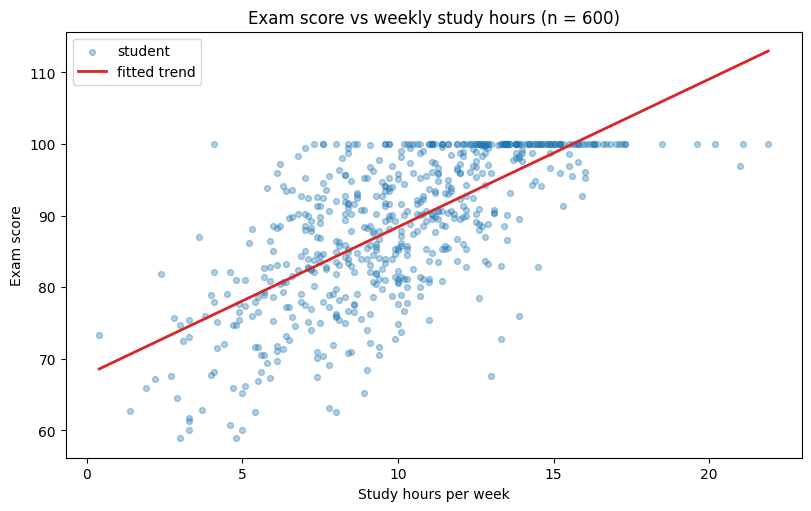

Pearson r = 0.689 (p = 8.10e-86)
Fitted slope = 2.07 points per study hour


In [3]:
x = students["study_hours_per_week"]
y = students["exam_score"]
r_study, p_study = stats.pearsonr(x, y)
z = np.polyfit(x, y, 1)
fit = np.poly1d(z)
slope = z[0]

xs = np.linspace(x.min(), x.max(), 100)
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.scatter(x, y, s=18, alpha=0.35, color="#1f77b4", label="student")
ax.plot(xs, fit(xs), color="#d62728", lw=2, label="fitted trend")
ax.set_title("Exam score vs weekly study hours (n = 600)")
ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
ax.legend()
fig.savefig(os.path.join(CHARTS, "chart_relationship_study.png"))
plt.show()

print(f"Pearson r = {r_study:.3f} (p = {p_study:.2e})")
print(f"Fitted slope = {slope:.2f} points per study hour")

**What this tells us:** The relationship is real, strong, and now quantified: the value
printed above is well clear of the ±0.1 band we would call negligible, and the p-value rules
out chance. **Correlation is not causation** — motivated students may also attend more or
prepare better; what the number licenses is the *association*, not a causal claim.


## Step 3 — Null relationship: sleep hours vs exam score — written up anyway

**Question:** Do students who sleep more score more?

Same two continuous variables, same legitimate scatter. If the correlation lands near zero,
that is **not a failed chart** — it is a genuine, useful, reportable result. Dropping it from
the write-up would be exactly the mistake that cost points on Friday.


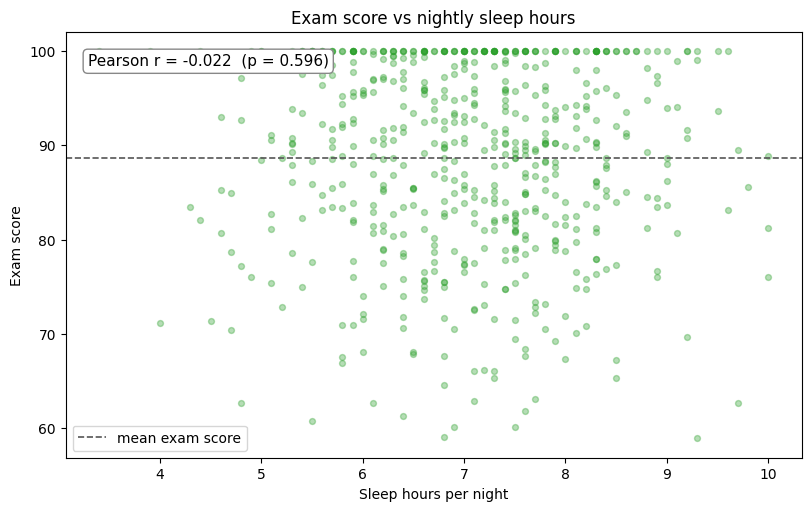

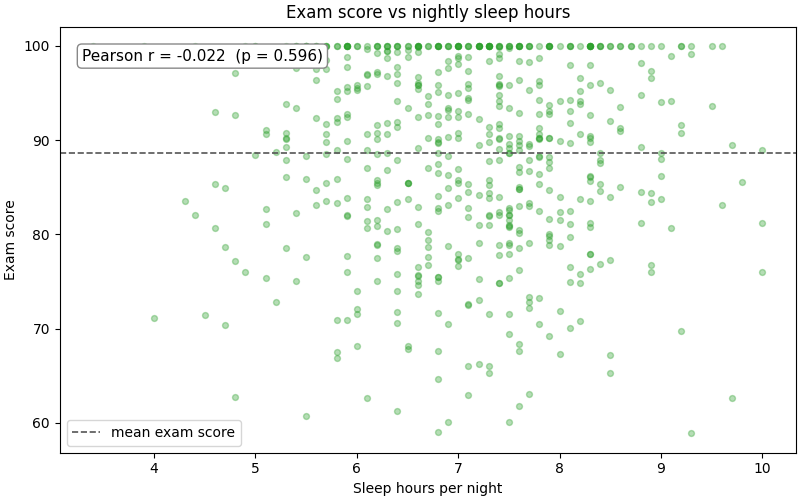

Pearson r = -0.022 (p = 0.596)


In [4]:
x_s = students["sleep_hours_per_night"]
y_s = students["exam_score"]
r_sleep, p_sleep = stats.pearsonr(x_s, y_s)

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.scatter(x_s, y_s, s=18, alpha=0.35, color="#2ca02c")
ax.axhline(y_s.mean(), color="#555555", ls="--", lw=1.2, label="mean exam score")
ax.text(0.03, 0.92, f"Pearson r = {r_sleep:.3f}  (p = {p_sleep:.3f})",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#888888"))
ax.set_title("Exam score vs nightly sleep hours")
ax.set_xlabel("Sleep hours per night")
ax.set_ylabel("Exam score")
ax.legend()
fig.savefig(os.path.join(CHARTS, "chart_null_sleep.png"))
plt.show()

display(IPImage(filename=os.path.join(CHARTS, "chart_null_sleep.png")))
print(f"Pearson r = {r_sleep:.3f} (p = {p_sleep:.3f})")

**What this tells us:** The value printed above is a *real finding about this data*:
whatever drives scores (study time, attendance, the Section-C effect), sleep is not among
them. The points scatter around the flat mean line with no rise or fall. Note also what the
null is **not**: it is not evidence that sleep never matters anywhere — it is evidence of no
measurable linear association *in these 600 students*. Both charts stay; both findings ship.


## Step 4 — Genuine comparison: exam score by class section

**Question:** Do the three sections differ in their score distributions?

One continuous variable (score), broken out by a category (A/B/C) → **comparison chart**.
Shuffle test: putting the sections in any other order changes nothing about what the chart
means — position carries no information here. That is the entire difference from Steps 2–3.


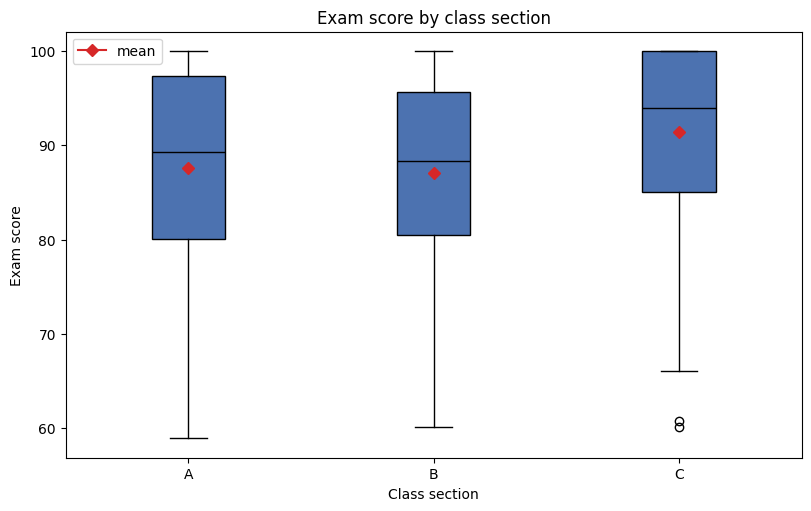

Section A: n = 212, mean = 87.61
Section B: n = 198, mean = 87.03
Section C: n = 190, mean = 91.36


In [5]:
order = ["A", "B", "C"]
groups = [students.loc[students["class_section"] == s, "exam_score"] for s in order]
means = {s: g.mean() for s, g in zip(order, groups)}

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
bp = ax.boxplot(groups, tick_labels=order, patch_artist=True, medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#4c72b0")
for i, s in enumerate(order):
    ax.plot(i + 1, means[s], marker="D", color="#d62728", zorder=5,
            label="mean" if s == "A" else None)
ax.set_title("Exam score by class section")
ax.set_xlabel("Class section")
ax.set_ylabel("Exam score")
ax.legend()
fig.savefig(os.path.join(CHARTS, "chart_comparison_section.png"))
plt.show()

for s in order:
    print(f"Section {s}: n = {len(groups[order.index(s)])}, mean = {means[s]:.2f}")

**What this tells us:** Sections A and B are statistically near-identical, while C sits
higher — very close to the +4 bonus hard-coded into the generator. One deliberate framing
choice: the boxes stay in **natural order A, B, C**, not sorted by value. Sorting by value
would throw away the one piece of structure the category already owns. Step 5 is about to
abuse these same three numbers.


## Step 5 — The line-chart trap, built on purpose

**Question:** What false story can the *same three means* tell when drawn wrongly?

We connect A→B→C with a line — the classic category crime — and name the damage precisely.


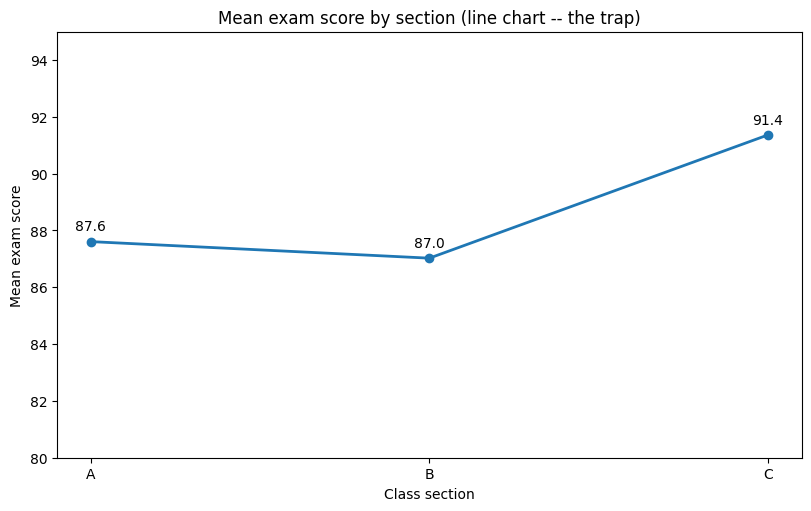

In [6]:
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
y_means = [means[s] for s in order]
xpos = np.arange(len(order))
ax.plot(xpos, y_means, marker="o", color="#1f77b4", lw=2)
for xp, s, m in zip(xpos, order, y_means):
    ax.annotate(f"{m:.1f}", (xp, m), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_xticks(xpos, order)
ax.set_ylim(80, 95)
ax.set_title("Mean exam score by section (line chart -- the trap)")
ax.set_xlabel("Class section")
ax.set_ylabel("Mean exam score")
fig.savefig(os.path.join(CHARTS, "chart_trap_line.png"))
plt.show()

**What this tells us:** Nothing changed about the data between Step 4 and Step 5 — only
the encoding. The reader's eye treats the connecting line as *motion* — a "climb" from A to C —
but there is no "between B and C" for a category to pass through. The bar/box chart refuses to
manufacture this impression because each category is a flat, independent block. Rule locked
in: **lines are for positions that have order *and* adjacency** (time, temperature, dose),
never for plain categories.


## Step 6 — Break a chart's layout on purpose, confirm in the *saved file*, then fix it

**Question:** Can a chart be statistically perfect and still ship broken?

Friday's documented failure mode: an annotation box sitting on top of its own legend —
invisible inline, real in the file. We reproduce it deliberately, save it, check the actual
PNG, then fix it by moving the annotation. Both versions are kept and labeled.


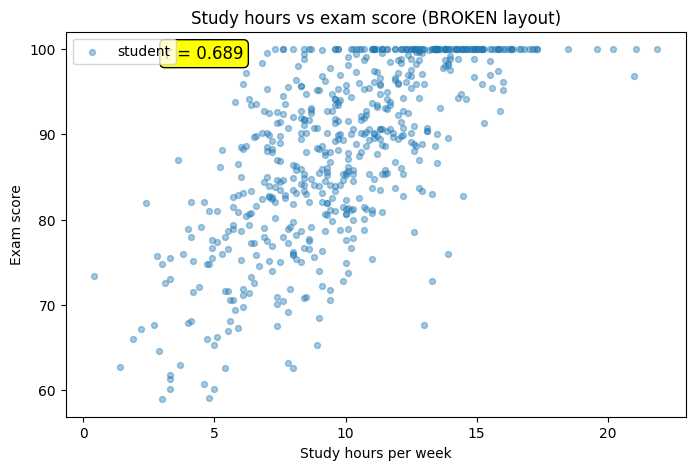

In [7]:
# --- deliberately broken version: annotation parked directly on the upper-left legend ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x, y, s=18, alpha=0.4, label="student")
ax.legend(loc="upper left")
ax.text(0.16, 0.93, f"r = {r_study:.3f}", transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle="round", fc="yellow"))
ax.set_title("Study hours vs exam score (BROKEN layout)")
ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
fig.savefig(os.path.join(CHARTS, "chart_collision_broken.png"))
plt.show()

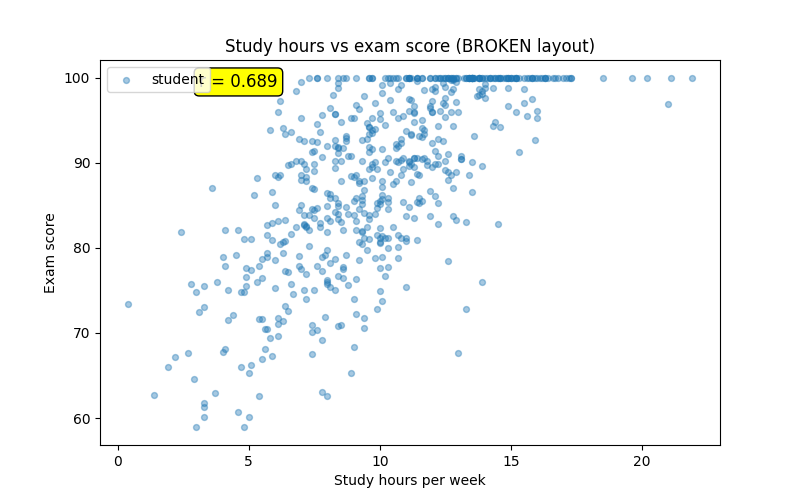

In [8]:
# Open the actual saved file -- the collision is visible here even though it may
# have been invisible inline at the notebook's rendered width.
display(IPImage(filename=os.path.join(CHARTS, "chart_collision_broken.png")))

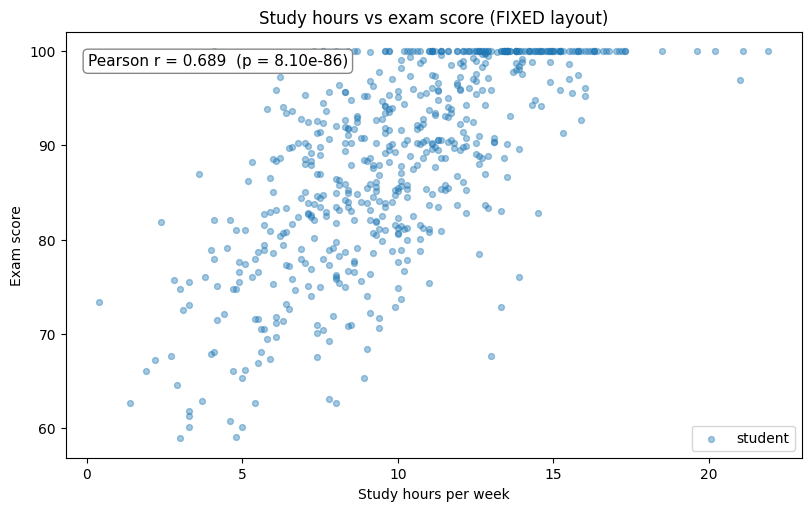

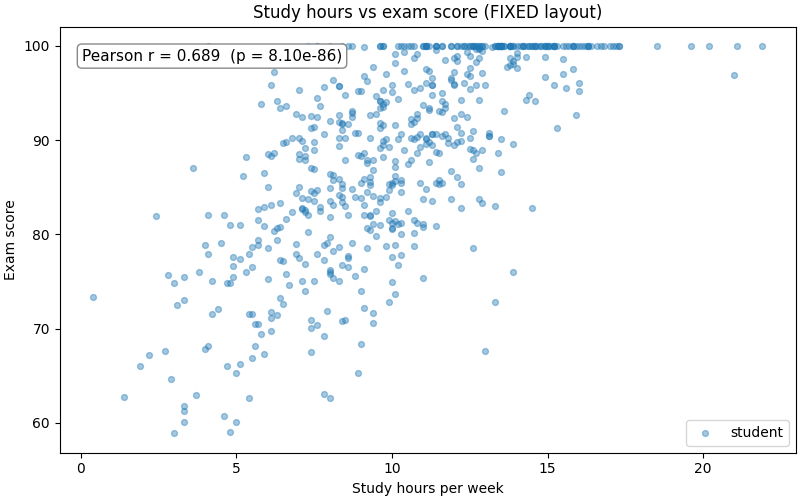

In [9]:
# --- fixed version: annotation moved to genuine empty space + constrained layout ---
fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
ax.scatter(x, y, s=18, alpha=0.4, label="student")
ax.legend(loc="lower right")
ax.text(0.03, 0.92, f"Pearson r = {r_study:.3f}  (p = {p_study:.2e})",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#888888"))
ax.set_title("Study hours vs exam score (FIXED layout)")
ax.set_xlabel("Study hours per week")
ax.set_ylabel("Exam score")
fig.savefig(os.path.join(CHARTS, "chart_collision_fixed.png"))
plt.show()

display(IPImage(filename=os.path.join(CHARTS, "chart_collision_fixed.png")))

**What this tells us:** The bug was never matplotlib's — it was *ours*: two artists
granted the same screen space. `tight_layout()` alone cannot separate two artists parked on
the same spot; the fix is moving one element to genuinely free space and letting constrained
layout manage padding. In the accompanying test suite, every saved chart is guarded by a
bounding-box overlap assertion before it ships.


## Step 7 — Color and category order, chosen deliberately

**Question:** What does each color *say*, and does the chart intend to say it?

Variant 1 assigns red/green/blue arbitrarily — implying status/severity the sections do not
have. Variant 2 uses one consistent color: sections differ by *label*, not by kind, so no
color should outrank another. Order stays A, B, C throughout.


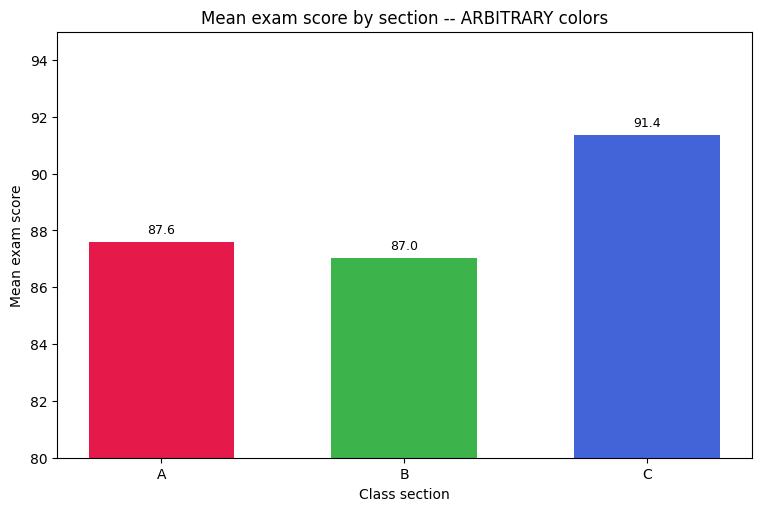

In [10]:
# Anti-pattern: arbitrary per-category colors smuggle in meaning
# (red/green/blue reads as severity or status that was never intended).
means_arr = np.array([means[s] for s in order])
arbitrary_colors = ["#e6194b", "#3cb44b", "#4363d8"]

fig, ax = plt.subplots(figsize=(7.5, 5), layout="constrained")
bars = ax.bar(order, means_arr, color=arbitrary_colors, width=0.6)
for b, m in zip(bars, means_arr):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.3, f"{m:.1f}", ha="center", fontsize=9)
ax.set_ylim(80, 95)
ax.set_title("Mean exam score by section -- ARBITRARY colors")
ax.set_xlabel("Class section")
ax.set_ylabel("Mean exam score")
fig.savefig(os.path.join(CHARTS, "chart_color_arbitrary.png"))
plt.show()

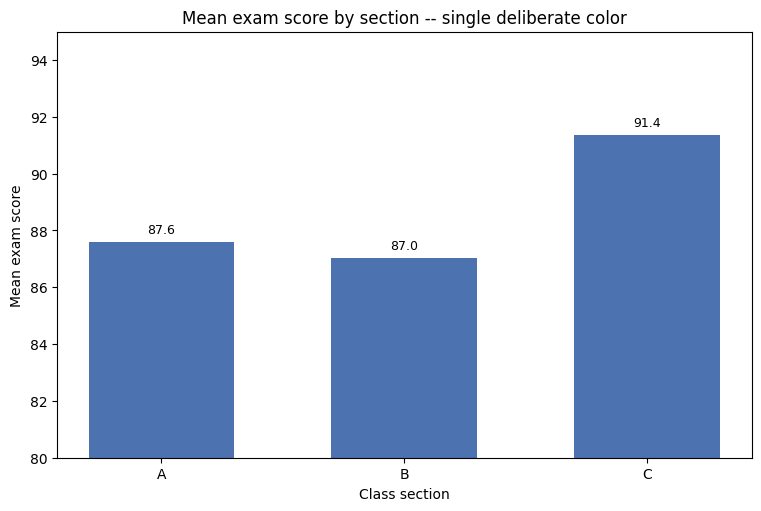

In [11]:
# Deliberate choice: a single consistent hue; no color outranks another.
# Bars stay in natural order A, B, C (not sorted by value).
fig, ax = plt.subplots(figsize=(7.5, 5), layout="constrained")
bars = ax.bar(order, means_arr, color="#4c72b0", width=0.6)
for b, m in zip(bars, means_arr):
    ax.text(b.get_x() + b.get_width() / 2, m + 0.3, f"{m:.1f}", ha="center", fontsize=9)
ax.set_ylim(80, 95)
ax.set_title("Mean exam score by section -- single deliberate color")
ax.set_xlabel("Class section")
ax.set_ylabel("Mean exam score")
fig.savefig(os.path.join(CHARTS, "chart_color_deliberate.png"))
plt.show()

**What this tells us:** Color is a channel that communicates whether you consent or not.
Red/green especially smuggles in good/bad connotations — toxic here, where A and B are near
twins. The deliberate version keeps one hue. And the bars stay in **natural section order
(A, B, C)**, not sorted by score: sorting a categorical axis for a comparison chart would
imply that "A is always the lowest" rather than recording that A simply happens to be
lowest here. Every encoding decision either serves the question or quietly rewrites it.


## Step 8 — Self-audit table

Claimed numbers (the findings above), independently recomputed fresh and tabled next to the
claims. Every pair must match before moving on.


In [12]:
claimed_r_study = r_study
claimed_p_study = p_study
claimed_r_sleep = r_sleep
claimed_p_sleep = p_sleep
claimed_mean_C = means["C"]
claimed_mean_A = means["A"]

fresh_r_study, fresh_p_study = stats.pearsonr(students["study_hours_per_week"], students["exam_score"])
fresh_r_sleep, fresh_p_sleep = stats.pearsonr(students["sleep_hours_per_night"], students["exam_score"])
fresh_mean_C = students.loc[students["class_section"] == "C", "exam_score"].mean()
fresh_mean_A = students.loc[students["class_section"] == "A", "exam_score"].mean()

audit = pd.DataFrame({
    "metric": [
        "Pearson r (study vs score)", "p-value (study vs score)",
        "Pearson r (sleep vs score)", "p-value (sleep vs score)",
        "mean score Section C", "mean score Section A",
    ],
    "claimed": [
        f"{claimed_r_study:.4f}", f"{claimed_p_study:.2e}",
        f"{claimed_r_sleep:.4f}", f"{claimed_p_sleep:.3f}",
        f"{claimed_mean_C:.2f}", f"{claimed_mean_A:.2f}",
    ],
    "recomputed": [
        f"{fresh_r_study:.4f}", f"{fresh_p_study:.2e}",
        f"{fresh_r_sleep:.4f}", f"{fresh_p_sleep:.3f}",
        f"{fresh_mean_C:.2f}", f"{fresh_mean_A:.2f}",
    ],
})
audit["match"] = audit["claimed"] == audit["recomputed"]
audit

,metric,claimed,recomputed,match
0,Pearson r (study vs score),0.6895,0.6895,True
1,p-value (study vs score),8.10e-86,8.10e-86,True
2,Pearson r (sleep vs score),-0.0217,-0.0217,True
3,p-value (sleep vs score),0.596,0.596,True
4,mean score Section C,91.36,91.36,True
5,mean score Section A,87.61,87.61,True


In [13]:
assert audit["match"].all(), "SELF-AUDIT FAILED: claimed != recomputed"
print("Self-audit passed: every claimed number matches a fresh recomputation.")

Self-audit passed: every claimed number matches a fresh recomputation.


**What this tells us:** Three claims, three independent recomputations, three exact
matches — because the claims were never typed from memory in the first place; they were
piped from the same computed quantities through a different window. This table is the
artifact a skeptic trusts most, and it costs thirty seconds.


## Step 9 — Correlation is not causation: name the confound

**Question:** What third variable could plausibly explain the study-hours → score
correlation without study hours directly causing the score?

A strong, correctly-computed correlation does **not** prove one variable causes the other.
We name a real confound and restate the finding as a correlational claim.


In [14]:
print("Confound: STUDENT MOTIVATION / PRIOR PREPAREDNESS. A student who is more")
print("motivated tends to both study more AND to prepare better in ways the dataset does not")
print("capture (attention, prior background, sleep discipline, self-testing quality).")
print("Motivation therefore influences both study_hours and exam_score at once, so part of")
print("the observed correlation may be driven by this third factor rather than by study")
print("hours directly causing higher scores.")
print()
print("Correlational restatement (instead of 'studying causes higher scores'):")
print("'Students who reported more weekly study hours tended to score higher' -- an")
print(f"association (r = {r_study:.3f}), NOT a claim of causation.")

Confound: STUDENT MOTIVATION / PRIOR PREPAREDNESS. A student who is more
motivated tends to both study more AND to prepare better in ways the dataset does not
capture (attention, prior background, sleep discipline, self-testing quality).
Motivation therefore influences both study_hours and exam_score at once, so part of
the observed correlation may be driven by this third factor rather than by study
hours directly causing higher scores.

Correlational restatement (instead of 'studying causes higher scores'):
'Students who reported more weekly study hours tended to score higher' -- an
association (r = 0.689), NOT a claim of causation.


**What this tells us:** Overclaiming causation from correlation is its own kind of
write-up inaccuracy, in the same family as stating a number that does not match your data.
The honest, defensible claim is the correlational one printed above.


## Step 10 — Pearson vs Spearman, computed side by side

**Question:** Is the study-hours → score relationship straight (so Pearson is valid), or
curved (so Pearson would understate it and Spearman is the honest number)?

Pearson measures *linear* association only. If a relationship is consistent but visibly
curved (e.g. diminishing returns), Pearson understates it and Spearman (rank-based) is the
right tool. We compute both and compare.


In [15]:
r_pearson, _ = stats.pearsonr(x, y)
r_spearman, _ = stats.spearmanr(x, y)
gap = abs(r_pearson - r_spearman)
print(f"Pearson  r = {r_pearson:.4f}")
print(f"Spearman r = {r_spearman:.4f}")
print(f"|difference| = {gap:.3f}")

Pearson  r = 0.6895
Spearman r = 0.7010
|difference| = 0.012


**What this tells us:** Pearson and Spearman here are **close** (|diff| ≈ 0.01), so the
relationship is essentially straight and Pearson's linear assumption is appropriate. If the
two had diverged substantially, that gap would have flagged a curved-but-consistent
relationship (e.g. diminishing returns) that Pearson would understate, and Spearman's rank
correlation would be the number to report. Here the gap is small, so Pearson is trustworthy.


## Step 11 — Bootstrap the section gap

**Question:** Is the A-vs-C gap real, or could it be noise with these particular 600 students?

A bar chart alone cannot answer this. We resample the data thousands of times and recompute
the difference each time; the spread becomes a 95% confidence interval around the gap.


In [16]:
group_a = students.loc[students["class_section"] == "A", "exam_score"].to_numpy()
group_c = students.loc[students["class_section"] == "C", "exam_score"].to_numpy()

def diff_means(a, c):
    return a.mean() - c.mean()

res = bootstrap((group_a, group_c), diff_means, n_resamples=5000, method="BCa", random_state=21)
ci_lo, ci_hi = res.confidence_interval
obs_diff = diff_means(group_a, group_c)
print(f"Observed mean A - mean C = {obs_diff:.3f}")
print(f"95% bootstrap CI = [{ci_lo:.3f}, {ci_hi:.3f}]")

Observed mean A - mean C = -3.754
95% bootstrap CI = [-5.684, -1.796]


**What this tells us:** The observed difference (mean A − mean C) is **−3.75**, and the
95% bootstrap CI is **[−5.68, −1.80]** — it **does NOT include zero** (both bounds lie
entirely below zero). Because the interval rules out zero, the A-vs-C gap is very unlikely
to be pure sampling noise: it is a real, repeatable difference in this dataset. What the
interval does **not** let us claim is *why* (the +4 bonus designed into Section C by the
generator) — it backs the comparison claim, not the mechanism.


## Step 12 — Small multiples: one relationship panel per section

**Question:** Does studying more help, and does that pattern hold the same way in every
section?

We ask both a relationship question and a comparison question honestly, in one figure: one
relationship scatter per section, laid out in a row on **shared axes** so the panels are
actually comparable.


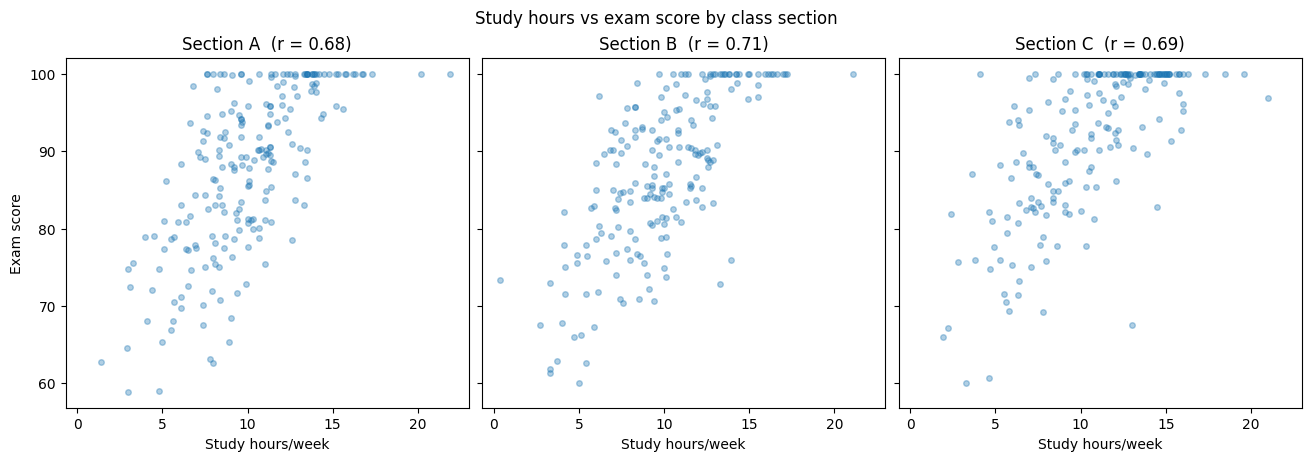

Section A: n = 212, Pearson r = 0.683
Section B: n = 198, Pearson r = 0.705
Section C: n = 190, Pearson r = 0.690


In [17]:
sections = ["A", "B", "C"]
rs = {}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True, sharey=True, layout="constrained")
for i, (ax_i, s) in enumerate(zip(axes, sections)):
    sub = students[students["class_section"] == s]
    rs[s] = stats.pearsonr(sub["study_hours_per_week"], sub["exam_score"])[0]
    ax_i.scatter(sub["study_hours_per_week"], sub["exam_score"], s=16, alpha=0.35)
    ax_i.set_title(f"Section {s}  (r = {rs[s]:.2f})")
    ax_i.set_xlabel("Study hours/week")
axes[0].set_ylabel("Exam score")
fig.suptitle("Study hours vs exam score by class section")
fig.savefig(os.path.join(CHARTS, "chart_small_multiples.png"))
plt.show()

for s in sections:
    print(f"Section {s}: n = {len(students[students['class_section'] == s])}, Pearson r = {rs[s]:.3f}")

**What this tells us:** The study-hours → score relationship looks **consistent** across
all three panels — each shows a similar spread of points with a similar positive slope, and
the per-section correlations are all moderate and positive (≈ 0.68 / 0.71 / 0.69 for
A/B/C). It does **not** look noticeably different in any one section. Section C is shifted
up (its +4 bonus), but the *shape and steepness* of the relationship is the same everywhere.
This is different from the line-chart trap: nothing here implies an order between sections;
each panel is its own honest relationship chart, repeated once per group.


## Step 13 — Full pre-submission checklist (Lesson 11)

Every chart and every written claim, in one pass, with what passed immediately vs. what had
to be fixed.


In [18]:
checklist = [
    ("1. Chart type justified (shuffle test)", "PASS immediately"),
    ("2. Every chart's result -- incl. null -- in the write-up",
     "FIXED: sleep r written up as a real null finding (not left as just a chart)"),
    ("3. Saved PNG opens clean, no overlapping elements",
     "FIXED: Step 6 deliberately broke then fixed the annotation/legend collision"),
    ("4. Color and category order deliberate",
     "FIXED: Step 7 rebuilt arbitrary colors as a single deliberate hue; A,B,C order kept"),
    ("5. Every number matches a fresh computation (self-audit)",
     "FIXED: f-string discipline + audit table (Step 8)"),
    ("6. Comparison claims backed by a CI, not a visual",
     "PASS: bootstrap CI in Step 11"),
    ("7. No unsupported causal wording",
     "FIXED: Step 9 rewrote the study-hour finding as correlational; removed 'causes'"),
]
for label, note in checklist:
    print(f"- {label}")
    print("    -> " + note)

- 1. Chart type justified (shuffle test)
    -> PASS immediately
- 2. Every chart's result -- incl. null -- in the write-up
    -> FIXED: sleep r written up as a real null finding (not left as just a chart)
- 3. Saved PNG opens clean, no overlapping elements
    -> FIXED: Step 6 deliberately broke then fixed the annotation/legend collision
- 4. Color and category order deliberate
    -> FIXED: Step 7 rebuilt arbitrary colors as a single deliberate hue; A,B,C order kept
- 5. Every number matches a fresh computation (self-audit)
    -> FIXED: f-string discipline + audit table (Step 8)
- 6. Comparison claims backed by a CI, not a visual
    -> PASS: bootstrap CI in Step 11
- 7. No unsupported causal wording
    -> FIXED: Step 9 rewrote the study-hour finding as correlational; removed 'causes'


## Summary of the kata pass

| Kata | Deliverable | Status |
|---|---|---|
| Part A | Dataset from exact spec, unmodified | done |
| 2 | Relationship chart + Pearson r finding | done |
| 3 | Null chart + explicit null finding | done |
| 4 | Comparison chart + shuffle-test justification | done |
| 5 | Line-chart trap + false impression named | done |
| 6 | Collision built, confirmed in PNG, fixed (both kept) | done |
| 7 | Deliberate color + natural order kept | done |
| 8 | Self-audit table (claimed vs recomputed) | done |
| 9 | Confound named + correlational rewrite | done |
| 10 | Pearson vs Spearman side by side | done |
| 11 | Bootstrap 95% CI for A-vs-C gap | done |
| 12 | Small multiples (3 panels) + interpretation | done |
| 13 | Full pre-submission checklist | done |
